# **Assignment: Machine Learning Project: "Loan Approval Prediction"**
**Submitted By:**
- **Name: Palwasha Sheikh**
- **GR: 772040**
  
- **Submitted To: Engr Nayab Bano**

# **Data Introduction:**

**Loan approval prediction is an important problem in the finance and banking sector. Financial companies receive a large number of loan applications every day, and manually checking each application can be time-consuming and inefficient. To reduce risk and improve decision-making, companies use customer information such as income, education, marital status, credit history, and loan amount to determine whether a loan should be approved or rejected.**

**The main objective of this project is to build a machine learning model that can predict loan eligibility based on customer details provided during the loan application process. By automating the loan approval process, financial institutions can make faster, more accurate, and more consistent decisions while reducing human effort and minimizing the risk of loan default.**

**This dataset contains demographic and financial information of applicants, including features such as Gender, Married Status, Dependents, Education, Applicant Income, Coapplicant Income, Loan Amount, Credit History, and Property Area. The target variable is Loan_Status, which indicates whether the loan application was approved or not.**

**In this project, Exploratory Data Analysis (EDA), data preprocessing, missing value treatment, outlier handling, and machine learning classification algorithms will be applied to analyze the data and predict loan approval status effectively.**

- # **Import Libraries:**

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


- # **Load/Read DataSet**

In [4]:
df= pd.read_csv('Loan Approval Prediction Training Dataset.csv')
print (df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

# **Data Overview/Data Understanding**

In [5]:
print("DATA SHAPE \n",df.shape)
print("=====================================================================================")
print("DATA COLUMNS \n",df.columns)
print("=====================================================================================")
print("DATA INFO \n",df.info())
print("=====================================================================================")
print("DATA DESCRIPTION \n",df.describe())
print("=====================================================================================")
print("LOAN APPROVAL COUNT \n",df['Loan_Status'].value_counts())
print("LOAN APPROVAL PERCENTAGE \n",df["Loan_Status"].value_counts(normalize=True)*100)

DATA SHAPE 
 (614, 13)
DATA COLUMNS 
 Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null 

**After reviewing the dataset, it is observed that the data contains 614 rows and 13 columns with a RangeIndex from 0 to 613. The dataset includes different data types such as float64 (4 columns), int64 (1 column), and object/string (8 columns). Some columns contain missing values, which will require preprocessing before model building. The target variable Loan_Status shows that approximately 68.72% of customers were approved for loans, while 31.27% were rejected, indicating a moderately imbalanced classification problem.**

# **Data Preprocessing**

- **Check Missing Values**

In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

- **Check Duplicates Values**

In [7]:
df.duplicated().sum()

np.int64(0)

**The dataset was checked for data quality issues, including missing values and duplicate records. No duplicate entries were found in the dataset. However, several columns contain missing values, including Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History. Therefore, missing value treatment will be required before proceeding with data analysis and machine learning model building.**

- **Handling Missing Vlues**

In [8]:
cols = ['Gender','Married','Dependents','Self_Employed','Loan_Amount_Term','Credit_History']
df[cols] = df[cols].apply(lambda x:x.fillna(x.mode()[0]))

df.fillna({'LoanAmount': df['LoanAmount'].median()},inplace=True)


In [9]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

**Missing values in categorical columns such as Gender, Married, Dependents, Loan_Amount_Term, Self_Employed, and Credit_History were filled using mode imputation because mode represents the most frequent category in each column and helps preserve the original distribution of the data. The missing values in the numerical column LoanAmount were filled using the median, as this feature may contain skewness and outliers. Median is more robust to extreme values and provides a better central representation than mean for skewed financial data.**

**Hence, after rechecking the dataset using the isnull() function, it was confirmed that all missing values had been successfully filled.**

- **Drop Unnecessary Columns**

In [10]:
df.drop(columns = ['Loan_ID'],inplace=True)
print(df)

     Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes         3+      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             8072   
612    Male     Yes          2      Graduate            No             7583   
613  Female      No          0      Graduate           Yes             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter

**The "loan_ID column has been droped because it has no use in analyzation**

# **Exploratory Data Analysis(EDA)**

- **Statistical Analysis**

   Statistical analysis is performed to understand the distribution, central tendency, and variability of numerical data. It also helps identify skewness and outliers before model building.

In [11]:
print('APPLICANT INCOME MEAN:', df['ApplicantIncome'].mean())
print('APPLICANT INCOME MEDIAN:', df['ApplicantIncome'].median())
print('APPLICANT INCOME MODE:', df['ApplicantIncome'].mode()[0])
print('APPLICANT INCOME STANDARD DEVIATION:', df['ApplicantIncome'].std())
print('APPLICANT INCOME VARIANCE:', df['ApplicantIncome'].var())
print("=====================================================================================")
print('LOAN AMOUNT MEAN:', df['LoanAmount'].mean())
print('LOAN AMOUNT MEDIAN:', df['LoanAmount'].median())
print('LOAN AMOUNT MODE:', df['LoanAmount'].mode()[0])
print('LOAN AMOUNT STANDARD DEVIATION:', df['LoanAmount'].std())
print('LOAN AMOUNT VARIANCE:', df['LoanAmount'].var())

APPLICANT INCOME MEAN: 5403.459283387622
APPLICANT INCOME MEDIAN: 3812.5
APPLICANT INCOME MODE: 2500
APPLICANT INCOME STANDARD DEVIATION: 6109.041673387174
APPLICANT INCOME VARIANCE: 37320390.167181164
LOAN AMOUNT MEAN: 145.75244299674267
LOAN AMOUNT MEDIAN: 128.0
LOAN AMOUNT MODE: 128.0
LOAN AMOUNT STANDARD DEVIATION: 84.10723338042615
LOAN AMOUNT VARIANCE: 7074.026706909471


- **The statistical analysis shows that the average applicant income is 5403.46, while the median income is 3812.5 and the mode is 2500. Since the mean is significantly higher than the median and mode, it indicates that the income distribution is positively skewed due to the presence of high-income outliers. The high standard deviation and variance also show that applicant incomes vary widely across the dataset.**

- **Similarly, the average loan amount is 145.75, whereas both the median and mode are 128, indicating that most applicants receive loan amounts around this value. The difference between mean and median suggests slight skewness in the loan amount distribution. Additionally, the standard deviation and variance indicate moderate variability in loan amounts among applicants.**

- **Groupby Analysis**

In [12]:
print(df.groupby('Loan_Status')['LoanAmount'].mean())
print('=====================================================================================')
print(df.groupby('Loan_Status')['ApplicantIncome'].mean())
print('=====================================================================================')
print(df.groupby('Education')['ApplicantIncome'].mean())

Loan_Status
N    149.890625
Y    143.869668
Name: LoanAmount, dtype: float64
Loan_Status
N    5446.078125
Y    5384.068720
Name: ApplicantIncome, dtype: float64
Education
Graduate        5857.433333
Not Graduate    3777.283582
Name: ApplicantIncome, dtype: float64


**The analysis shows that Applicant Income and Loan Amount have only a slight difference between approved and rejected loans, indicating weak direct influence. However, Education level shows a clear difference in income, suggesting it is an important factor affecting financial status.**

- **Credit History VS Loan Status LOAN (in Crosstab)**

    Crosstab is used to analyze the relationship between two categorical variables by showing their frequency distribution in a tabular form.

In [13]:
pd.crosstab(df['Credit_History'],df['Loan_Status'])

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,110,415


**Credit history has a very strong impact on loan approval. Applicants with good credit history (1.0) are far more likely to get loan approval compared to those with poor credit history (0.0).**

- **CHI-SQUARE TEST**

    The Chi-Square test checks whether there is a relationship between two categorical variables or whether they are independent of each other.

In [14]:
table = pd.crosstab(df['Credit_History'],df['Loan_Status'])
chi2, p, dof, expected = chi2_contingency(table)
print('p-value:',p)

p-value: 3.4183499979091188e-40


**The Chi-Square test resulted in a very small p-value (3.41e-40), which indicates a statistically significant relationship between Credit History and Loan Status. Therefore, credit history is a strong predictor of loan approval.**

- **SKEWNESS CHECK**

    Check Skewness whether the data is evenly distributed or tilted to one side, and it also helps in identifying extreme values (outliers) in numerical data.

In [15]:
print(df[['ApplicantIncome', 'LoanAmount']].skew())

ApplicantIncome    6.539513
LoanAmount         2.743053
dtype: float64


### Data Distribution & Skewness Analysis

* **The Problem:** Both `ApplicantIncome` and `LoanAmount` have very high positive skewness (scores of 6.54 and 2.74). This means most applicants have lower incomes/loans, but a few extremely rich applicants are skewing the data with huge numbers (outliers).
* **The Impact:** These extreme high values can confuse the machine learning model and ruin its predictions.
* **The Solution:** We need to apply a **Log Transformation** to both features before training the model. This will squash down the massive numbers and make the data more balanced and easier for the model to understand.

- **Data Visualization**

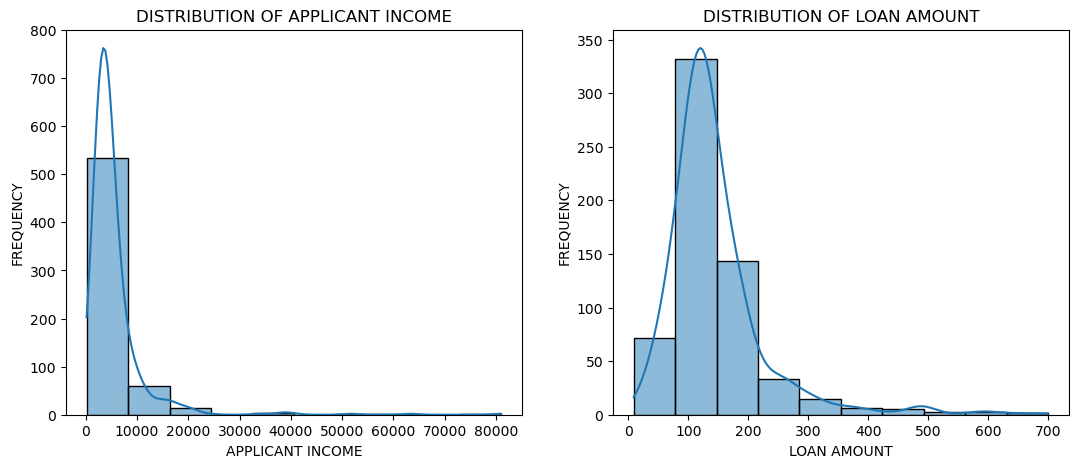

In [16]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['ApplicantIncome'],bins = 10,kde=True)
plt.title('DISTRIBUTION OF APPLICANT INCOME')
plt.xlabel('APPLICANT INCOME')
plt.ylabel('FREQUENCY')

plt.subplot(1, 3, 2)
sns.histplot(df['LoanAmount'],bins = 10,kde=True)
plt.title('DISTRIBUTION OF LOAN AMOUNT')
plt.xlabel('LOAN AMOUNT')
plt.ylabel('FREQUENCY')

plt.show()

**The histogram of Applicant Income shows that most applicants fall in the lower income range. Fewer applicants are seen in the higher income range, meaning high-income individuals are less common. This results in a right-skewed distribution, where the data is concentrated on the lower side with a few high-income outliers on the right.**

**The histogram shows the distribution of loan amounts given to applicants. It can be observed that most of the loan amounts are concentrated in the lower range (around 100–200)., while fewer applicants receive very high loan amounts. This creates a right-skewed distribution, meaning the data is not evenly spread and is pulled towards higher values due to a few large loans (outliers).**

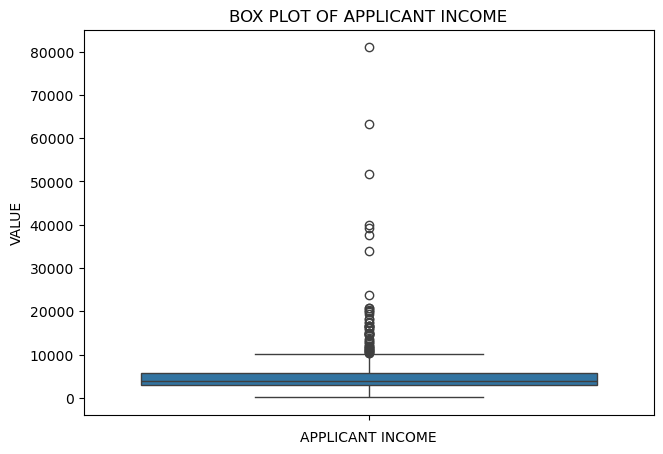

In [17]:
plt.figure(figsize =(25,5))
plt.subplot(1,3,1)
sns.boxplot(df['ApplicantIncome'])
plt.title('BOX PLOT OF APPLICANT INCOME')
plt.xlabel('APPLICANT INCOME')
plt.ylabel('VALUE')
plt.show()

**The box plot shows the distribution and outliers in applicant income. Most applicants have income in the lower range (around 3000–6000).The middle line (median) shows typical income around that range.There are many outliers above 10,000, some even reaching 80,000+.**

**Hence: Applicant income is highly spread and right-skewed, with a large number of extreme high-income outliers compared to the majority of applicants.**

C:\Users\Aaqeeb Mushtaq\AppData\Local\Temp\ipykernel_1092\3787243510.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_loan = df.groupby('Income_Group')['LoanAmount'].mean()


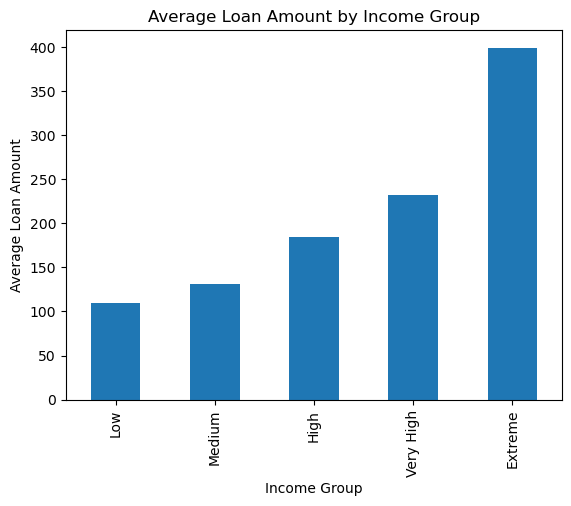

In [18]:

df['Income_Group'] = pd.cut(
    df['ApplicantIncome'],
    bins = [0,3000,6000,9000,20000,90000],
    labels = ['Low', 'Medium', 'High', 'Very High','Extreme']
)
avg_loan = df.groupby('Income_Group')['LoanAmount'].mean()
avg_loan.plot(kind = 'bar')
plt.title("Average Loan Amount by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Loan Amount")

plt.show()

**The graph shows the average loan amount across different income groups. It can be observed that applicants with higher income levels generally receive higher loan amounts. Lower-income applicants tend to receive smaller loans, while high and very high-income groups have comparatively larger average loan amounts. This indicates a positive relationship between applicant income and loan approval amount.**

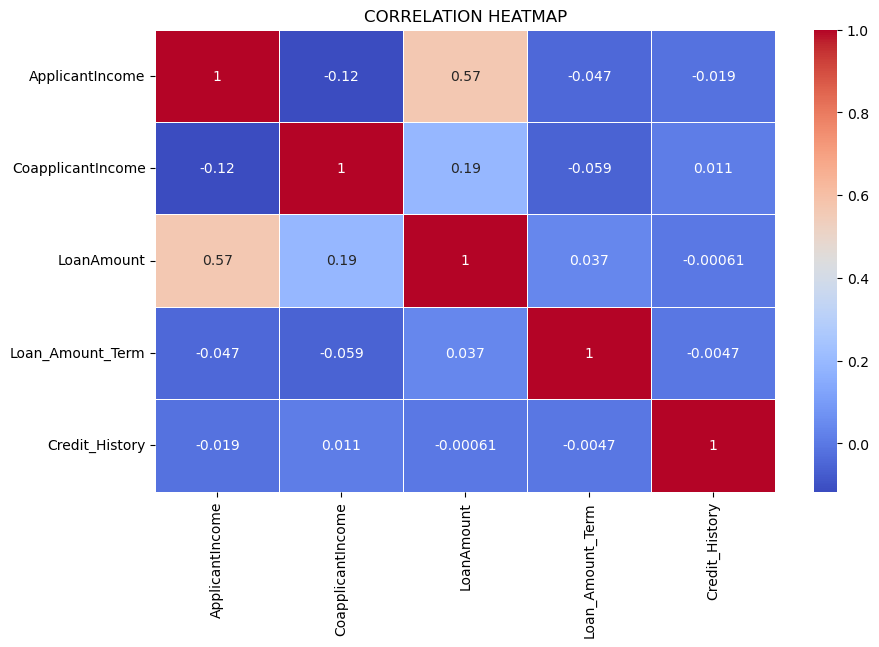

In [19]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('CORRELATION HEATMAP')
plt.show()

**The above correlation heatmap shows the relationships between different numerical variables in the dataset.**

- **Applicant Income & Loan Amount = 0.57 (Moderate positive correlation)**
This indicates that higher applicant income is generally associated with higher loan amounts.
- **Coapplicant Income & Loan Amount = 0.19 (Weak positive correlation)**
This shows a slight relationship, but coapplicant income does not strongly influence the loan amount.
- **Credit History & other variables ≈ 0 (Very weak or no linear correlation)**
Credit history does not show a strong linear relationship with the numerical features in this view.
- **Loan Amount Term (Very weak correlation with other variables)**
Loan term does not significantly correlate with income or loan amount in this dataset.

**Overall, Applicant Income is the only variable showing a noticeable relationship with Loan Amount, while the other features exhibit weak or negligible linear correlations.**

- **GroupBy Analysis & Feature Removal**

In [20]:
df= df.drop(['Income_Group'], axis = 1)

**During exploratory data analysis, group-by analysis was performed on selected (ApplicantIncome) to understand their relationship with the target variable. However, the derived feature (Income_Group) was later removed from the dataset as it was not suitable for model training and was causing issues during SMOTE processing**

- **Encoding**

In [21]:
le = LabelEncoder()
df[['Gender','Married','Education','Self_Employed','Loan_Status']]  = df[['Gender','Married','Education','Self_Employed','Loan_Status']].apply(le.fit_transform)

print('\n LABEL ENCODING(GENDER,MARRIED,EDUCATION,SELF_EMPLOYED,LOAN_STATUS)')
print(df[['Gender','Married','Education','Self_Employed','Loan_Status']])


 LABEL ENCODING(GENDER,MARRIED,EDUCATION,SELF_EMPLOYED,LOAN_STATUS)
     Gender  Married  Education  Self_Employed  Loan_Status
0         1        0          0              0            1
1         1        1          0              0            0
2         1        1          0              1            1
3         1        1          1              0            1
4         1        0          0              0            1
..      ...      ...        ...            ...          ...
609       0        0          0              0            1
610       1        1          0              0            1
611       1        1          0              0            1
612       1        1          0              0            1
613       0        0          0              1            0

[614 rows x 5 columns]


In [22]:
df= pd.get_dummies(df, columns=['Dependents','Property_Area'], dtype=int)
print('\n ONE-HOT ENCODING(DEPENDENTS,PROPERTY_AREA)')
print(df.head())


 ONE-HOT ENCODING(DEPENDENTS,PROPERTY_AREA)
   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       1        0          0              0             5849   
1       1        1          0              0             4583   
2       1        1          0              1             3000   
3       1        1          1              0             2583   
4       1        0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Loan_Status  Dependents_0  Dependents_1  Dependents_2  Dependents_3+  \
0            1             1             0             0            

- **Split Data For Training and Testing**

In [23]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("TRAINING DATA:\n", X_train)
print("TESTING DATA:\n", X_test)

TRAINING DATA:
      Gender  Married  Education  Self_Employed  ApplicantIncome  \
83        1        1          0              0             6000   
90        1        1          0              0             2958   
227       1        1          0              0             6250   
482       1        1          0              0             2083   
464       1        0          0              0             4166   
..      ...      ...        ...            ...              ...   
71        1        1          1              1             1875   
106       1        1          0              0            11417   
270       0        0          0              0             3237   
435       0        1          0              0            10047   
102       1        1          0              0            13650   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
83              2250.0       265.0             360.0             1.0   
90              2900.0       131.0 

- **Apply Standard Scaler**

In [24]:
standardscaler = StandardScaler()
col = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
X_train[col] = standardscaler.fit_transform(X_train[col])
X_test[col] = standardscaler.transform(X_test[col])    
print("STANDARD SCALED TRAINING DATA:\n", X_train[col].head(5))
print("STANDARD SCALED TESTING DATA:\n", X_test[col].head(5))

STANDARD SCALED TRAINING DATA:
      ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term
83          0.083915           0.180667    1.355734          0.287611
90         -0.429338           0.385430   -0.197609          0.287611
227         0.126095           0.005831    0.718168          0.287611
482        -0.576970           0.464185   -0.232385          0.287611
464        -0.225522          -0.528127   -0.580149          0.287611
STANDARD SCALED TESTING DATA:
      ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term
350         0.604085          -0.528127    0.926826          0.287611
377        -0.201226          -0.528127   -0.209201          0.287611
163        -0.225353          -0.072293    0.115378          0.287611
609        -0.439124          -0.528127   -0.893136          0.287611
132        -0.469831          -0.528127   -0.904728          0.287611


**StandardScaler is applied to numerical features like 'ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term' to normalize their values. This ensures that all features are on a similar scale, which helps the model perform more effectively and improves convergence.**

- **SMOTE (for Imbalanced Data)**

In [36]:
sm = SMOTE(random_state = 42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [30]:
print('BEFORE SMOTE:')
print (y_train.value_counts(normalize = True) * 100)
print('=====================================================================================')
print('AFTER SMOTE:')
print(y_res.value_counts(normalize= True) *100)

BEFORE SMOTE:
Loan_Status
1    69.653768
0    30.346232
Name: proportion, dtype: float64
AFTER SMOTE:
Loan_Status
0    50.0
1    50.0
Name: proportion, dtype: float64


**The dataset initially had an imbalanced distribution, where 69.65% of applications were approved (Loan_Status = Y) and 30.35% were rejected (Loan_Status = N). This imbalance could bias the model toward predicting loan approvals more frequently. To handle this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied, which generated synthetic samples for the minority class. After applying SMOTE, the dataset became perfectly balanced with 50% approved (Y) and 50% rejected (N), improving the model’s ability to learn both classes equally and make more reliable predictions..**

# **Model Building**

- **Logistic Regression Model**

In [37]:
lr_model = LogisticRegression(max_iter=500,random_state=42)
lr_model.fit(X_res, y_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


**The Logistic Regression model was trained on SMOTE-balanced data to improve the prediction of both loan approval (Y) and rejection (N) classes, ensuring fair learning from the previously imbalanced dataset.**

In [39]:
y_pre_lr = lr_model.predict(X_test)
print(y_pre_lr)

[1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1
 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 0 1 1 1 0 1 1 1 0 1 1 1]


**The Logistic Regression model predicts loan approval (1) or rejection (0) for each applicant in the test dataset, based on the learned patterns from the SMOTE-balanced training data.**

- **Decision Tree Classifier Model**

In [46]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_res,y_res)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**"To identify patterns in the data, the Decision Tree model was trained on SMOTE_Balanced data."**

In [47]:
y_pre_dt = dt_model.predict(X_test)
print(y_pre_dt)

[1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 0
 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 1 0 0
 0 1 1 1 1 1 1 0 0 1 1 0]


**"Predictions were made on the test dataset using the trained Decision Tree model."**

- **Random Forest Classifier Model**

In [48]:
rf_model = RandomForestClassifier()
rf_model.fit(X_res, y_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**"A Random Forest model was built and trained on SMOTE_Balanced data to make predictions of both loan approval (Y) and rejection (N) classes, combining multiple decision trees to improve accuracy and reduce overfitting."**

In [49]:
y_pre_rf = rf_model.predict(X_test)
print(y_pre_rf)

[1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 0 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0
 0 1 1 0 1 1 1 0 0 1 1 1]


**"Predictions were made on the test dataset using the trained Random Forest Classifier model."**

# **Data Evaluation**

- **Classification Report**

In [52]:
print('LOGISTIC REGRESSION CLASSIFIER REPORT:\n' , classification_report(y_test, y_pre_lr))
print('========================================================================================')
print('DECISION TREE CLASSIFIER REPORT:\/n' , classification_report(y_test, y_pre_dt))
print('========================================================================================')
print('RANDOM FOREST CLASSIFIER REPORT:\n' , classification_report(y_test, y_pre_rf))

LOGISTIC REGRESSION CLASSIFIER REPORT:
               precision    recall  f1-score   support

           0       0.73      0.51      0.60        43
           1       0.77      0.90      0.83        80

    accuracy                           0.76       123
   macro avg       0.75      0.71      0.72       123
weighted avg       0.76      0.76      0.75       123

DECISION TREE CLASSIFIER REPORT:\/n               precision    recall  f1-score   support

           0       0.57      0.56      0.56        43
           1       0.77      0.78      0.77        80

    accuracy                           0.70       123
   macro avg       0.67      0.67      0.67       123
weighted avg       0.70      0.70      0.70       123

RANDOM FOREST CLASSIFIER REPORT:
               precision    recall  f1-score   support

           0       0.61      0.44      0.51        43
           1       0.74      0.85      0.79        80

    accuracy                           0.71       123
   macro avg      

# **Comparison Summary:** 

- **The Logistic Regression model outperforms both the Decision Tree and Random Forest classifiers across almost all key metrics on this dataset.Overall Accuracy: Logistic Regression achieved the highest overall accuracy ($76\%$), compared to Decision Tree ($70\%$) and Random Forest ($71\%$).**
  
- **Class 1 (Majority Class): All three models perform well on Class 1, but Logistic Regression yields the highest F1-score ($0.83$) and the best Recall ($0.90$), meaning it catches $90\%$ of actual Class 1 instances.**
  
- **Class 0 (Minority Class): Class 0 is challenging for all models due to fewer samples (Support = 43). However, Logistic Regression provides the highest Precision ($0.73$), meaning when it predicts Class 0, it is correct $73\%$ of the time, though its Recall is lower ($0.51$).**

- **"HENCE: Logistic Regression is the recommended model here as it provides the most balanced performance and the highest overall predictive power."**

- **Confusion Matrixs**

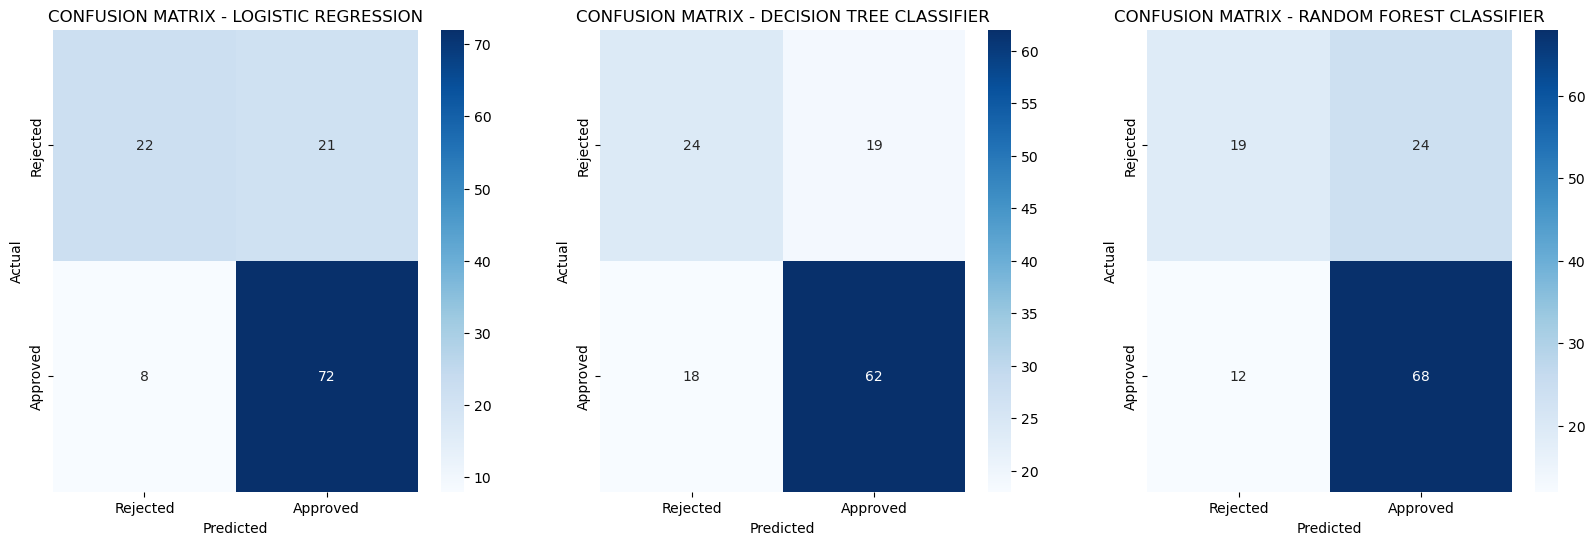

In [62]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pre_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = ['Rejected','Approved'],
            yticklabels = ['Rejected','Approved'])
plt.title('CONFUSION MATRIX - LOGISTIC REGRESSION')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,3,2)
cm = confusion_matrix(y_test,y_pre_dt)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])
plt.title('CONFUSION MATRIX - DECISION TREE CLASSIFIER')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,3,3)
cm = confusion_matrix(y_test,y_pre_rf)
sns.heatmap(cm,annot=True, fmt= 'd',cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels = ['Rejected', 'Approved']  
)
plt.title('CONFUSION MATRIX - RANDOM FOREST CLASSIFIER')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**The confusion matrices provide a detailed look at how each model handles correct and incorrect predictions for both classes (Rejected and Approved):**

- **True Positives (Approved correctly identified): Logistic Regression performs the best by correctly predicting 72 approved cases, followed by Random Forest (68) and Decision Tree (62).**

- **True Negatives (Rejected correctly identified): Decision Tree performs slightly better here by correctly identifying 24 rejected cases, compared to Logistic Regression (22) and Random Forest (19).**

- **False Negatives (Approved misclassified as Rejected): Logistic Regression minimizes this error significantly, with only 8 missed approved cases, whereas Decision Tree misses 18 and Random Forest misses 12.**

- **"Conclusion:"**

**While the Decision Tree is slightly better at identifying rejected applications, Logistic Regression is the most reliable overall model because it significantly maximizes true positive counts (72) and minimizes critical false negative errors (8).**

# **Overall Business Summary:**

**1. BUSINESS PROBLEM:**

Financial institutions face challenges in efficiently and accurately determining whether a loan application should be approved or rejected. Manual decision-making can be slow, inconsistent, and influenced by bias.

**Key business challenges:**
- Risk of approving high-risk applicants (False Positives)
  
- Loss of potential good customers due to manual errors (False Negatives)

- Imbalanced dataset affecting prediction reliability

- Need for an automated, data-driven decision system

**2. SOLUTION:**
A machine learning-based loan approval prediction system was developed to automate and optimize the decision-making process.

**Steps performed:**

- Data cleaning and missing value handling
  
- Exploratory Data Analysis (EDA)

- Feature encoding (Label Encoding & One-Hot Encoding)

- Feature scaling using StandardScaler

- Handling class imbalance using SMOTE

**Models trained:**

- Logistic Regression

- Decision Tree Classifier

- Random Forest Classifier

**Model evaluation:**

- Classification Report (Precision, Recall, F1-Score)

- Confusion Matrix

**3. KEY INSIGHTS (BUSINESS ANALYSIS):**

- Credit history remains the most critical factor in loan approval decisions.

- Applicant income shows a moderate influence on the final loan amount.

- Dataset was imbalanced before applying SMOTE, which helped stabilize model training.

- The majority of applicants fall into the lower-to-middle income range.

- Outliers exist in the income distribution, requiring robust scaling.

**4. RECOMMENDATIONS:**

- **Model Deployment:** Deploy the Logistic Regression model into production as it delivers the highest accuracy ($76\%$) and the most balanced performance across both classes.

- **Risk Management:** Utilize Logistic Regression specifically to minimize financial risk, as it has the lowest False Negatives (only 8 missed approved applications).

- **Workflow Integration:** Integrate this automated system into the frontline loan approval workflow to cut down manual processing time from days to seconds.

# **FINAL CONCLUSION:**

**Machine learning models were developed to predict loan approval using applicants' financial and demographic data. The dataset was thoroughly preprocessed using encoding, scaling, and SMOTE to ensure unbiased model performance.**

**Three classifiers—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated. Among these, Logistic Regression achieved the superior overall performance with the highest accuracy ($76\%$) and a dominant F1-score ($0.83$) for approved loans.**

**Confusion matrix analysis verified that Logistic Regression made significantly fewer critical misclassifications, capturing 72 out of 80 true approved cases successfully. While the Decision Tree showed a minor advantage in catching rejections, Logistic Regression offered the most reliable, robust, and commercially viable balance.**

**"Hence, Logistic Regression is confidently selected as the optimal model for the automated loan approval prediction system."**